# Big Data Analytics Project - Spring 2026

### Group 16 Members:

- Ana Margarida Macedo (20250405) 
- Catarina Aboim ()
- Margarida Craveiro ()
- Matilde Simões ()
- Lourenço Silva (20250453)

### <font color= '#0000FF'>**Methodology** </font><a class="anchor" id='top'></a>

- [1. Setup](#1)
- [2. Import Libraries](#2)
- [3. Metadata](#3)
- [4. Import Datasets](#4)
- [5. Data Cleaning](#5)

<a class="anchor" id="1">

# **1. Metadata**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="1.1">

## **1.1 Yellow Taxis Dataset**

[Back to TOP](#TOP)
</a>

**VendorID**: A code indicating the TPEP provider that provided the record.
- 1 = Creative Mobile Technologies, LLC
- 2 = Curb Mobility, LLC
- 6 = Myle Technologies Inc
- 7 = Helix

**tpep_pickup_datetime**: The date and time when the meter was engaged.

**tpep_dropoff_datetime**: The date and time when the meter was disengaged.

**passenger_count**: The number of passengers in the vehicle.

**trip_distance**: The elapsed trip distance in miles reported by the taximeter.

**RatecodeID**: The final rate code in effect at the end of the trip.
- 1 = Standard rate
- 2 = JFK
- 3 = Newark
- 4 = Nassau or Westchester
- 5 = Negotiated fare
- 6 = Group ride
- 99 = Null/unknown

**store_and_fwd_flag**: This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka "store and forward," because the vehicle did not have a connection to the server.
- Y = store and forward trip
- N = not a store and forward trip

**PULocationID**: TLC Taxi Zone in which the taximeter was engaged.

**DOLocationID**: TLC Taxi Zone in which the taximeter was disengaged.

**payment_type**: A numeric code signifying how the passenger paid for the trip.
- 0 = Flex Fare trip
- 1 = Credit card
- 2 = Cash
- 3 = No charge
- 4 = Dispute
- 5 = Unknown
- 6 = Voided trip

**fare_amount**: The time-and-distance fare calculated by the meter. For additional information on the following columns, see https://www.nyc.gov/site/tlc/passengers/taxi-fare.page

**extra**: Miscellaneous extras and surcharges.

**mta_tax**: Tax that is automatically triggered based on the metered rate in use.

**tip_amount**: Tip amount – This field is automatically populated for credit card tips. Cash tips are not included.

**tolls_amount**: Total amount of all tolls paid in trip.

**improvement_surcharge**: Improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015.

**total_amount**: The total amount charged to passengers. Does not include cash tips.

**congestion_surcharge**: Total amount collected in trip for NYS congestion surcharge.

**airport_fee**: For pick up only at LaGuardia and John F. Kennedy Airports.

<a class="anchor" id="1.2">

## **1.2 Financial Fraud Detection Dataset**

[Back to TOP](#TOP)
</a>

**step**: Represents a unit of time in the real world, with 1 step equating to 1 hour. The total simulation spans 744 steps, equivalent to 30 days.

**type**: Transaction types include CASH-IN, CASH-OUT, DEBIT, PAYMENT, and TRANSFER.

**amount**: The transaction amount in the local currency.

**nameOrig**: The customer initiating the transaction.

**oldbalanceOrg**: The initial balance before the transaction.

**newbalanceOrig**: The new balance after the transaction.

**nameDest**: The transaction's recipient customer.

**oldbalanceDest**: The initial recipient's balance before the transaction. Not applicable for customers identified by 'M' (Merchants).

**newbalanceDest**: The new recipient's balance after the transaction. Not applicable for 'M' (Merchants).

**isFraud**: Identifies transactions conducted by fraudulent agents aiming to deplete customer accounts through transfers and cash-outs.

**isFlaggedFraud**: Flags large-scale, unauthorized transfers between accounts, with any single transaction exceeding 200,000 being considered illegal.

<a class="anchor" id="2">

# **2. Setup**

[Back to TOP](#TOP)
</a>

In [2]:
!pip install pyspark
!pip install pandas
!pip install matplotlib
!pip install kagglehub # to import Financial Fraud dataset

# Install Java 17
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless

Get:1 https://packages.cloud.google.com/apt cloud-sdk InRelease [1621 B]
Get:2 https://download.docker.com/linux/ubuntu noble InRelease [48.5 kB]       
Hit:3 https://cli.github.com/packages stable InRelease                         
Get:4 https://packages.cloud.google.com/apt cloud-sdk/main amd64 Packages [4640 kB]
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Get:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:7 https://download.docker.com/linux/ubuntu noble/stable amd64 Packages [59.1 kB]
Get:8 https://packages.cloud.google.com/apt cloud-sdk/main all Packages [1982 kB]
Get:9 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:10 https://cloud.archive.ubuntu.com/ubuntu noble InRelease [256 kB]        
Hit:11 http://deb.wakemeops.com/wakemeops stable InRelease                     
Get:12 https://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]    
Get:13 https://cloud

In [2]:
# Confirm Java 17 install
!java -version

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-124.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-124.04.1, mixed mode, sharing)


# 3. Library and Dataset Imports

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import kagglehub # to import Financial Fraud dataset
import pandas as pd
import matplotlib.pyplot as plt
import os
from pyspark.sql.functions import col, desc

from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

In [4]:
# Set JAVA_HOME to Java 17
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"


In [5]:
# Start Spark session
spark = SparkSession.builder \
    .appName("BDA-Project") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/07 21:40:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Yellow Taxis Dataset

Context: In New York City, yellow taxis (medallion cabs) can pick up passengers anywhere, while green taxis (Boro Taxis) are restricted to hailing in outer boroughs and upper Manhattan. Both use meters and are regulated. Elsewhere, yellow often indicates high-visibility, traditional, or airport-focused services, while green may represent eco-friendly or specialized suburban vehicles

In [6]:
#!wget -P data/ https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2015-01.parquet
#!wget -P data/ https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2016-01.parquet
#!wget -P data/ https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2016-02.parquet
#!wget -P data/ https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2016-03.parquet

Having Jan 2015 + Jan/Feb/Mar 2016 lets us do year-over-year comparison (Jan 2015 vs Jan 2016) AND a short 3-month trend within 2016.

In [7]:
# Load data as DataFrames
df_taxi_012025 = (
    spark.read
    .parquet("data/yellow_tripdata_2015-01.parquet")
)
df_taxi_012026 = (
    spark.read.parquet("data/yellow_tripdata_2016-01.parquet")
)
df_taxi_022026 = (
    spark.read.parquet("data/yellow_tripdata_2016-02.parquet")
)
df_taxi_032026 = (
    spark.read.parquet("data/yellow_tripdata_2016-03.parquet")
)

In [8]:
# Load all taxi datasets as one
df_taxi_all = (
    spark.read
    .parquet("data/yellow_tripdata_*.parquet")
)

26/04/06 22:57:46 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: data/yellow_tripdata_*.parquet.
java.io.FileNotFoundException: File data/yellow_tripdata_*.parquet does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.sql.cat

## Financial Fraud Dataset

In [6]:
# Download latest version
path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
['Synthetic_Financial_datasets_log.csv']


In [7]:
csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")

# Load as DataFrame
df = spark.read.csv(csv_file, header=True, inferSchema=True)
df.show(5)

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PAYMENT| 1864.28|C1666544295|      21249.0|      19384.72|M2044282225|           0.0|           0.0|      0|             0|
|   1|TRANSFER|   181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|
|   1|CASH_OUT|   181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|
|   1| PAYMENT|11668.14|C2048537720|      41554.0|      29885.86|M1230701703|      

In [11]:
# Se for necessário ter o ficheiro na pasta do Git:
# Copy to your project folder
# shutil.copytree(path, "data/", dirs_exist_ok=True)

# 4. EDA

## 4.1. Yellow Taxis Dataset

### 4.1.1. Preview

In [12]:
print(
    f"df_taxi_012025 (Jan 2015): Rows: {df_taxi_012025.count():,}, Cols: {len(df_taxi_012025.columns)}\n"
    f"df_taxi_012026 (Jan 2016): Rows: {df_taxi_012026.count():,}, Cols: {len(df_taxi_012026.columns)}\n"
    f"df_taxi_022026 (Feb 2016): Rows: {df_taxi_022026.count():,}, Cols: {len(df_taxi_022026.columns)}\n"
    f"df_taxi_032026 (Mar 2016): Rows: {df_taxi_032026.count():,}, Cols: {len(df_taxi_032026.columns)}\n"
    f"df_taxi_all    (merged)  : Rows: {df_taxi_all.count():,}, Cols: {len(df_taxi_all.columns)}"
)

df_taxi_012025 (Jan 2015): Rows: 12,741,035, Cols: 19
df_taxi_012026 (Jan 2016): Rows: 10,905,067, Cols: 19
df_taxi_022026 (Feb 2016): Rows: 11,375,412, Cols: 19
df_taxi_032026 (Mar 2016): Rows: 12,203,824, Cols: 19
df_taxi_all    (merged)  : Rows: 47,225,338, Cols: 19


In [13]:
# For .parquet files, the schema is predefined: long, double
df_taxi_all.printSchema()

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: void (nullable = true)
 |-- airport_fee: void (nullable = true)



!! Not big data safe without .limit() !!

In [14]:
df_taxi_all.limit(5).toPandas()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None


### 4.1.2 Anomaly Detection (RDD)

Zero-distance trips

The goal of this section is to identify record anomalies within the dataset—specifically "Zero-distance paid trips". These are transactions where the passenger was charged a fare (total_amount > 0), but the recorded GPS distance was zero (trip_distance == 0).

While Spark DataFrames are more modern and optimized, we are using RDDs (Resilient Distributed Datasets) here to perform low-level, row-based filtering. This allows us to understand how Spark distributes functional transformations across a cluster.

In [15]:
#convert the dataframe to RDD
taxi_rdd = df_taxi_all.rdd

#Apply a map transformation to the taxi_rdd.
#For each row, it extracts the VendorID, trip_distance and total_amount, creating a new RDD with these specific fields.
mapped_rdd = taxi_rdd.map(lambda row: (row.VendorID, row.trip_distance, row.total_amount))

anomalies_rdd = mapped_rdd.filter(lambda x: x[1] == 0 and x[2] > 0)

#counts the total number of anomalies found
n_anomalies = anomalies_rdd.count()
print(f"Zero-distance paid trips: {n_anomalies}")

#retrieves and prints the first 10 examples of these anomalies
print("\nExamples of anomalies:")
for row in anomalies_rdd.take(5):
    print(row)

Zero-distance paid trips: 259943

Examples of anomalies:


(1, 0.0, 3.8)
(1, 0.0, 15.3)
(1, 0.0, 3.8)
(2, 0.0, 15.8)
(1, 0.0, 3.8)


The filtering process revealed 259943 records where the trip_distance is 0.0 but the total_amount is greater than 0.

These records represent approximately a significant portion of the dataset that could skew economic analysis (like average fare per mile).

Potential Causes: These anomalies typically correspond to:

1. Fixed Fees: Minimum fares or cancellation fees where the vehicle did not move.

2. Sensor Errors: GPS or odometer malfunctions during a trip.

3. Wait Time: Passengers being charged for waiting time while the taxi remained stationary.

For the subsequent "Fare per Mile" analysis in section 4.1.3, these records must be excluded. Calculating a ratio with a denominator of zero would lead to mathematical errors or infinite values, misleading the business insights.

### 4.1.3 RDD EDA

Fare per mile by vendor

This section calculates the **average fare per mile** for each taxi vendor. By aggregating the total revenue and total distance traveled per vendor, we can compare their pricing efficiency.

#### Methodology
To ensure accurate results, we follow these steps using the RDD API:
1. **Cleaning**: We filter out records with `trip_distance <= 0` or `total_amount <= 0` based on our previous anomaly analysis.
2. **Mapping**: We create key-value pairs where the key is the `VendorID` and the value is a tuple `(total_amount, trip_distance)`.
3. **Reduction**: Using `reduceByKey`, we sum the fares and distances for each vendor across the entire distributed dataset.
4. **Computation**: A final map transformation calculates the ratio: `Sum of Fares / Sum of Distances`.

In [16]:
#Filter valid data and create (VendorID, (price, distance)) pairs
taxi_totals_rdd = df_taxi_all.rdd \
    .filter(lambda row: row.trip_distance > 0 and row.total_amount > 0) \
    .map(lambda row: (row.VendorID, (row.total_amount, row.trip_distance)))

# Sum the values by VendorID
# 'a' and 'b' represent tuples of (price, distance) from two different rows
vendor_sum_rdd = taxi_totals_rdd.reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))

# Calculate the final average (Total Price / Total Distance)
# For each vendor, x[0] is the VendorID, x[1][0] is the sum of money, and x[1][1] is the sum of distance.
fare_per_mile_rdd = vendor_sum_rdd.map(lambda x: (x[0], x[1][0] / x[1][1]))

print("Results: Average Fare per Mile by Vendor")
results = fare_per_mile_rdd.collect()
for vendor, avg_fare in results:
    print(f"Vendor ID: {vendor} | Average Fare per Mile: ${avg_fare:.2f}")

Results: Average Fare per Mile by Vendor


Vendor ID: 1 | Average Fare per Mile: $1.30
Vendor ID: 2 | Average Fare per Mile: $5.35


The RDD aggregation revealed a significant disparity between the two vendors:
* **Vendor 1:** Approximately $1.30 per mile.
* **Vendor 2:** Approximately $5.35 per mile.

Vendor 2 is significantly more expensive per mile (over 4x higher than Vendor 1). This suggests that Vendor 2 likely operates in dense urban areas (like Manhattan) where short trips incur high base fares and slow-moving traffic increases the cost relative to the distance. In contrast, Vendor 1's lower rate suggests longer-distance trips, possibly airport transfers or highway routes, where the cost per mile is naturally diluted.

### 4.1.4. DF EDA - Null Analysis and Distributions

In [17]:
# Numeric columns only — clean and readable
df_taxi_all.select(
    "fare_amount", "trip_distance", "passenger_count", 
    "tip_amount", "total_amount"
).describe().toPandas()

26/04/06 23:10:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,summary,fare_amount,trip_distance,passenger_count,tip_amount,total_amount
0,count,47225338,47225338,47225338,47225338,47225338
1,mean,12.393463581351163,7.0687238134746,1.6672329798888894,1.7953061221057502,15.594838232471584
2,stddev,78.62711409194661,6210.993538039544,1.322272394889288,574.8814034203128,580.2820110377311
3,min,-957.6,0.0,0,-220.8,-958.4
4,max,429496.72,1.90726288E7,9,3950588.8,3950611.6


In [18]:
null_counts = df_taxi_all.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) 
    for c in df_taxi_all.columns
])

null_counts.toPandas().T.rename(columns={0: "null_count"}) \
           .sort_values("null_count", ascending=False)

,null_count
airport_fee,47225338
congestion_surcharge,47225338
improvement_surcharge,3
tpep_dropoff_datetime,0
tpep_pickup_datetime,0
VendorID,0
passenger_count,0
PULocationID,0
trip_distance,0
RatecodeID,0


In [19]:
# Payment type breakdown
df_taxi_all.groupBy("payment_type") \
           .count() \
           .withColumn("pct", F.round(F.col("count") / df_taxi_all.count() * 100, 2)) \
           .orderBy("count", ascending=False) \
           .toPandas()

# Vendor breakdown
df_taxi_all.groupBy("VendorID").count().toPandas()

,VendorID,count
0,1,22214556
1,2,25010782


<Axes: title={'center': 'Trips by Hour of Day'}, xlabel='hour'>

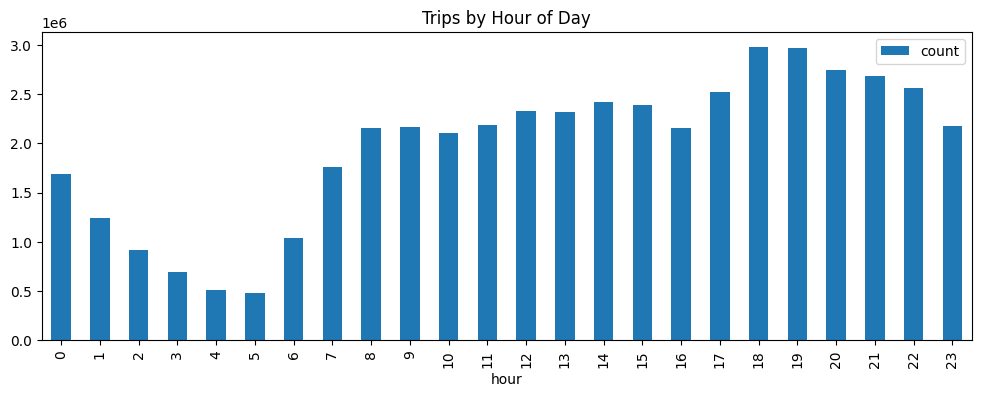

In [20]:
# Trips by hour of day
df_taxi_all.withColumn("hour", F.hour("tpep_pickup_datetime")) \
           .groupBy("hour") \
           .count() \
           .orderBy("hour") \
           .toPandas() \
           .plot(x="hour", y="count", kind="bar", 
                 title="Trips by Hour of Day", figsize=(12,4))

### 4.1.5. SparkSQL- Temporal Analysis and YoY comparison

## Financial Fraud Detection Dataset

# Preprocessing

## Yellow Taxis Dataset

Enforcing Schema

In [21]:
# Example:
schema = StructType([
    StructField("price",             IntegerType(), True),
    StructField("area",              IntegerType(), True),
    StructField("bedrooms",          IntegerType(), True),
    StructField("bathrooms",         IntegerType(), True),
    StructField("stories",           IntegerType(), True),
    StructField("mainroad",          StringType(),  True),
    StructField("guestroom",         StringType(),  True),
    StructField("basement",          StringType(),  True),
    StructField("hotwaterheating",   StringType(),  True),
    StructField("airconditioning",   StringType(),  True),
    StructField("parking",           IntegerType(), True),
    StructField("prefarea",          StringType(),  True),
    StructField("furnishingstatus",  StringType(),  True),
])

## Financial Fraud Detection Dataset

### 4.2.1 Data Profiling and Schema Inspection
Using the Spark DataFrame API, we first inspect the distribution of transaction types and the prevalence of fraud within the dataset. This high-level view helps identify which categories require deeper RDD-based analysis.

In [23]:
#View count by transaction type
df.groupBy("type").count().orderBy(col("count").desc()).show()

#View the percentage of fraud in the total dataset
total_count = df.count()
fraud_count = df.filter("isFraud = 1").count()
print(f"Percentage of fraudulent transactions: {(fraud_count/total_count)*100:.4f}%")

+--------+-------+
|    type|  count|
+--------+-------+
|CASH_OUT|2237500|
| PAYMENT|2151495|
| CASH_IN|1399284|
|TRANSFER| 532909|
|   DEBIT|  41432|
+--------+-------+



Percentage of fraudulent transactions: 0.1291%


Initial exploration reveals a massive but extremely imbalanced dataset, where fraudulent transactions represent only 0.1291% of the total volume.

In a Big Data context, this confirms that fraud detection is a "needle in a haystack" problem. High-level profiling using the DataFrame API is essential to isolate these rare events before performing more granular, row-based RDD transformations.

In [10]:
df.cache() 
print(f"Dataset cached. Total records: {df.count()}")

26/04/07 21:43:18 WARN MemoryStore: Not enough space to cache rdd_33_2 in memory! (computed 76.7 MiB so far)
26/04/07 21:43:18 WARN BlockManager: Persisting block rdd_33_2 to disk instead.
26/04/07 21:43:22 WARN MemoryStore: Not enough space to cache rdd_33_2 in memory! (computed 76.7 MiB so far)
26/04/07 21:43:22 WARN MemoryStore: Not enough space to cache rdd_33_2 in memory! (computed 76.7 MiB so far)


Dataset cached. Total records: 6362620


### 4.2.2 RDD-based Aggregation: Total Fraudulent Amount per Type
Following the MapReduce paradigm, we transition to the RDD API to perform a custom aggregation. We aim to calculate the total monetary volume of fraud for each transaction type to determine where the highest financial risk lies.

In [24]:
#Map: (type, amount) only for frauds
fraud_map = df.filter("isFraud = 1").rdd.map(lambda row: (row.type, row.amount))

#Reduce: Sum the values
fraud_totals = fraud_map.reduceByKey(lambda a, b: a + b)

print("Total Stolen Amount per Transaction Type:")
for tType, total in fraud_totals.collect():
    print(f"- {tType}: ${total:,.2f}")

Total Stolen Amount per Transaction Type:


- TRANSFER: $6,067,213,184.01
- CASH_OUT: $5,989,202,243.83


By implementing the MapReduce pattern (map followed by reduceByKey), the analysis identified a staggering financial impact exceeding $12 billion in total losses.

The losses are almost equally split between TRANSFER ($6.06B) and CASH_OUT ($5.99B). This symmetry suggests a structured criminal "two-step" pattern: funds are first moved to a secondary account via a Transfer and immediately liquidated through a Cash Out to erase the digital trail.

### 4.2.3 Integrity Check: Balance Consistency Analysis
A common indicator of fraud is a discrepancy between the transaction amount and the account's balance change. We implement a validation logic to flag transactions where the balance was not updated correctly.

In [25]:
#Pure function to check integrity
def is_balance_consistent(row):
    #Check if (Initial Balance - Final Balance) is equal to the Amount (with an error margin of 0.01)
    diff = abs((row.oldbalanceOrg - row.newbalanceOrig) - row.amount)
    return diff < 0.01

# Apply the filter and count inconsistencies i
inconsistent_frauds = df.filter("isFraud = 1").rdd.filter(lambda r: not is_balance_consistent(r))
print(f"Fraudulent transactions with inconsistent balances: {inconsistent_frauds.count()}")

Fraudulent transactions with inconsistent balances: 45


The application of a Pure Function for validation (as practiced in early functional programming labs) uncovered 45 fraudulent transactions where a logical inconsistency exists between the transaction amount and the resulting account balance.

These cases represent critical anomalies where standard banking validation logic was likely bypassed. Utilizing the RDD API for this check allowed for a detailed, row-by-row verification that ensures data integrity across the distributed system.

### 4.2.4 Visualization of Financial Loss by Transaction Type
To better communicate the financial impact, we visualize the total amount lost to fraud across different categories. This helps prioritize security measures for the most vulnerable transaction channels.

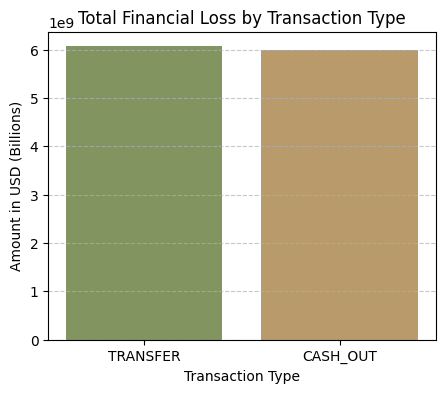

In [31]:
#Convert the RDD result to a Pandas DataFrame
pdf = fraud_summary_df.toPandas()

#Create a bar chart with transaction types and total amounts
plt.figure(figsize=(5, 4))
plt.bar(pdf['Transaction_Type'], pdf['Total_Amount'], color=['#829460', '#B99B6B'])
plt.title('Total Financial Loss by Transaction Type')
plt.ylabel('Amount in USD (Billions)')
plt.xlabel('Transaction Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The graphical visualization reinforces that fraud is not random but highly targeted. The financial volume in TRANSFER and CASH_OUT is disproportionately higher compared to other transaction types, which show zero or negligible fraudulent activity.

This visualization provides stakeholders with a clear priority map, suggesting that real-time monitoring and security resources should be concentrated on these two specific transaction channels to mitigate the vast majority of financial risk.

### 4.2.5 Identification of Potential "Money Mule" Accounts
To further investigate the fraud network, we performed a grouping analysis on the destination accounts (`nameDest`). Unlike victim accounts, which are usually targeted once, destination accounts that appear multiple times in fraudulent transactions are highly likely to be controlled by the fraudulent agents.

In [32]:
#See which accounts receive the most fraudulent money
df.filter("isFraud = 1") \
  .groupBy("nameDest") \
  .agg(F.count("isFraud").alias("fraud_count"), 
       F.sum("amount").alias("total_stolen")) \
  .orderBy(F.col("fraud_count").desc()) \
  .show(10)

+-----------+-----------+------------+
|   nameDest|fraud_count|total_stolen|
+-----------+-----------+------------+
| C200064275|          2|      8847.0|
|C1366192319|          2|  7061799.65|
|C1827219533|          2|   907503.17|
| C410033330|          2|   133781.84|
| C935310781|          2|   544064.51|
| C475338087|          2|   730733.52|
|C1601170327|          2|  2842694.99|
| C104038589|          2|  2202769.97|
| C185805228|          2|  1124385.07|
| C904300960|          2|  1427683.17|
+-----------+-----------+------------+
only showing top 10 rows


**Findings:**
1. The top 10 destination accounts were each involved in at least 2 high-value fraudulent transactions. 
2. Certain accounts aggregated financial volumes exceeding **$7 million**, highlighting their role as primary nodes in the money laundering process.
3. This grouping technique using `groupBy` and `agg` (aggregated functions) demonstrates how Spark can be used to identify complex network patterns across millions of records that would be invisible in a row-by-row analysis.

In [33]:
df.createOrReplaceTempView("fraud_data")

spark.sql("""
    WITH fraud_tiers AS (
        SELECT amount, type,
               CASE 
                   WHEN amount > 1000000 THEN 'High Impact'
                   WHEN amount > 100000 THEN 'Medium Impact'
                   ELSE 'Low Impact'
               END as impact_level
        FROM fraud_data
        WHERE isFraud = 1
    )
    SELECT impact_level, COUNT(*) as count, SUM(amount) as total
    FROM fraud_tiers
    GROUP BY impact_level
    ORDER BY total DESC
""").show()

+-------------+-----+--------------------+
| impact_level|count|               total|
+-------------+-----+--------------------+
|  High Impact| 2706|1.046072230894999...|
|Medium Impact| 3800|1.5226730667999992E9|
|   Low Impact| 1707| 7.302005209000005E7|
+-------------+-----+--------------------+



By registering the dataset as a Temporary View and utilizing Spark SQL, it was possible to segment the fraudulent activities into tiered impact levels. This approach, leveraging Common Table Expressions (CTEs) and Conditional Logic (CASE statements), provides a clear business-centric view of financial risk, proving that the majority of stolen volume is concentrated in high-impact transactions exceeding $1,000,000.

### 4.2.6 Advanced Feature Engineering: Balance Depletion Ratio
Following the techniques from Lab 6, we implement a User-Defined Function (UDF) to calculate the "Depletion Ratio". This metric represents the percentage of the origin account's balance that was moved in a single transaction, providing a normalized view of the financial impact on the victim.

In [ ]:
def calculate_depletion_ratio(amount, oldbalance):
    if oldbalance == 0:
        return 0.0
    return float(amount / oldbalance)

depletion_udf = udf(calculate_depletion_ratio, DoubleType())


df_enriched = df.withColumn("depletion_ratio", depletion_udf(F.col("amount"), F.col("oldbalanceOrg")))

df_enriched.filter("isFraud = 1").select("amount", "oldbalanceOrg", "depletion_ratio").show(5)

+-------+-------------+---------------+
| amount|oldbalanceOrg|depletion_ratio|
+-------+-------------+---------------+
|  181.0|        181.0|            1.0|
|  181.0|        181.0|            1.0|
| 2806.0|       2806.0|            1.0|
| 2806.0|       2806.0|            1.0|
|20128.0|      20128.0|            1.0|
+-------+-------------+---------------+
only showing top 5 rows


### 4.2.7 Analytical Window Functions: Cumulative Exposure per Account
Using Spark Window Functions, we track the cumulative amount moved by each account over time (steps). This allows us to identify accounts that are being drained progressively, a common pattern in sophisticated fraud schemes.

In [9]:
from pyspark.sql.window import Window

# Definir a janela: por conta de origem, ordenada pelo tempo (step)
windowSpec = Window.partitionBy("nameOrig").orderBy("step")

# Calcular o valor acumulado
df_accumulated = df_enriched.withColumn("cumulative_amount", F.sum("amount").over(windowSpec))

# Mostrar contas que movimentaram valores críticos acumulados
df_accumulated.filter("isFraud = 1").orderBy(F.desc("cumulative_amount")).select("nameOrig", "step", "amount", "cumulative_amount").show(10)

+-----------+----+------+-----------------+
|   nameOrig|step|amount|cumulative_amount|
+-----------+----+------+-----------------+
|C1208192074| 362| 1.0E7|            1.0E7|
|C1237313447|  82| 1.0E7|            1.0E7|
|C1198427314| 586| 1.0E7|            1.0E7|
|C1519426085| 469| 1.0E7|            1.0E7|
|C1028530067| 238| 1.0E7|            1.0E7|
| C124022062| 250| 1.0E7|            1.0E7|
|C1348396248| 118| 1.0E7|            1.0E7|
|C1004068843| 710| 1.0E7|            1.0E7|
|C1440908860| 714| 1.0E7|            1.0E7|
|C1251439451| 212| 1.0E7|            1.0E7|
+-----------+----+------+-----------------+
only showing top 10 rows
